=== RAPPORT FINAL - PRÉDICTION DES ÉTATS DES DATACENTERS ===

RÉSUMÉ DU PROJET PFA

1. Dataset utilisé :
   → Server Machine Dataset (SMD) - 28 machines
   → 38 métriques par machine (CPU, RAM, réseau, disque...)

2. Pré-traitement :
   → Nettoyage des données
   → Analyse des features (feature_5 ≈ RAM, feature_0-3 ≈ CPU...)

3. Augmentation des données :
   → 4 versions par machine (original, noise, scaled, shift_noise)
   → Total : 112 fichiers augmentés

4. Fenêtres temporelles :
   → Taille de fenêtre : 60 minutes
   → Stride : 10 minutes
   → Total fenêtres créées : ~70 687

5. Modèle utilisé :
   → Isolation Forest (détection d'anomalies)
   → Entraîné sur 5000 fenêtres

6. Résultats :
   → Anomalies détectées : 250 / 5000 (5.00%)


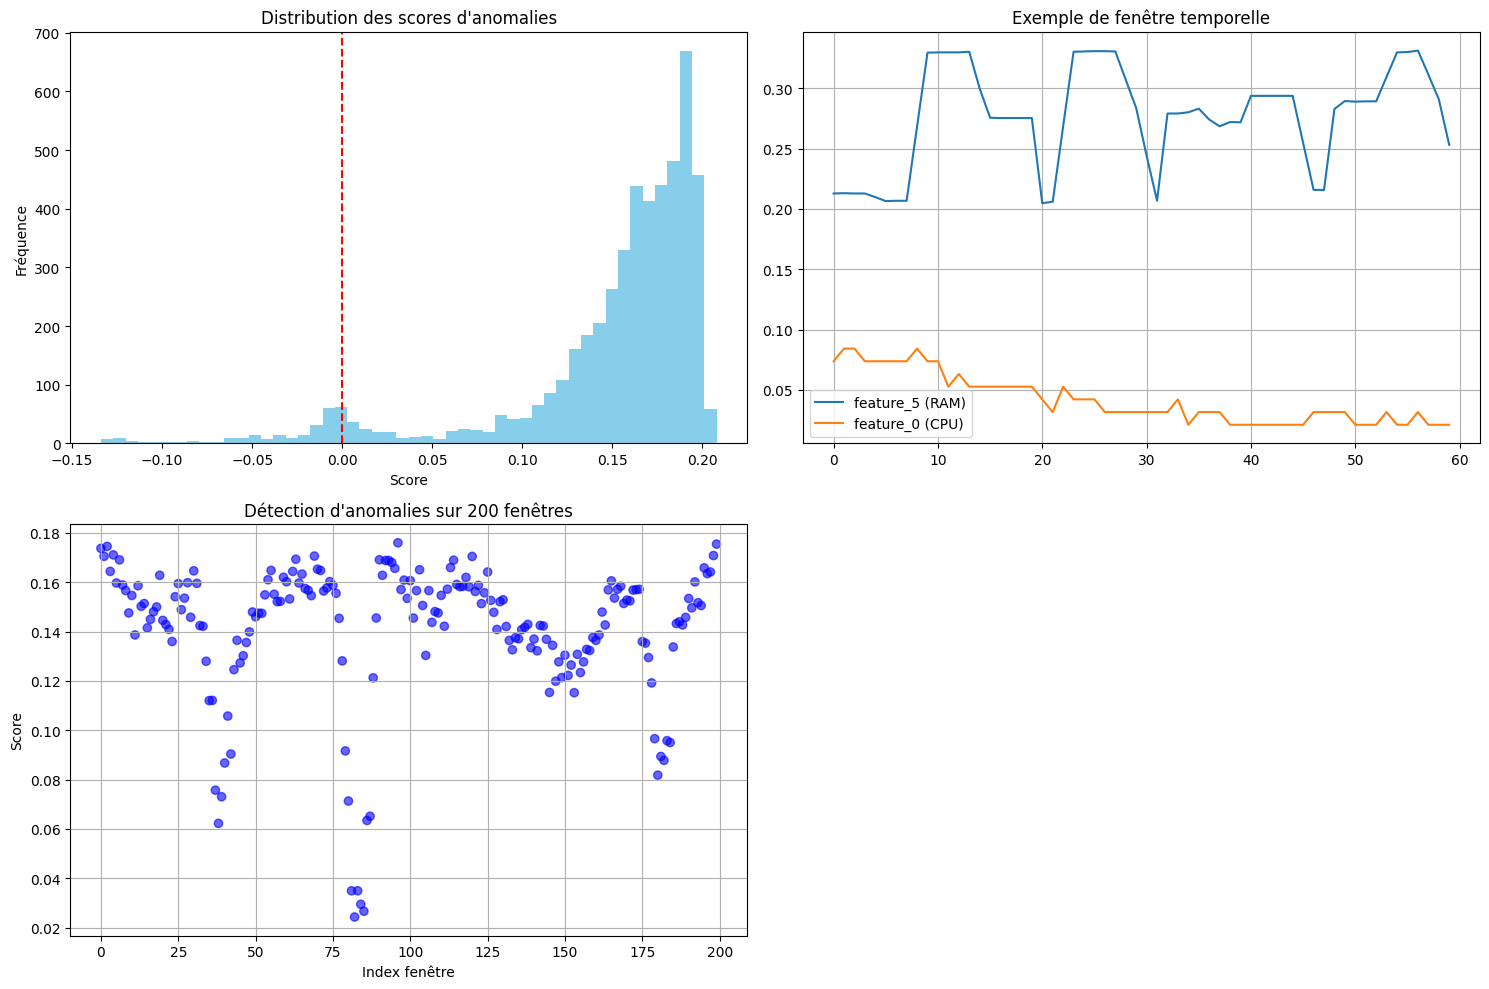


✅ Projet terminé avec succès !
Fichiers importants créés :
   • models/isolation_forest_model.pkl
   • data/processed/windows/X_windows.npy
   • reports/rapport_summary.txt

Conseils pour ton rapport PFA :
- Parle du SMD dataset
- Explique pourquoi tu as fait de l'augmentation
- Montre l'utilité des sliding windows
- Présente les résultats de détection d'anomalies
- Mentionne les limites (modèle léger à cause de la machine)

Tu peux maintenant exporter ce notebook en PDF pour ton rapport.


In [1]:
import numpy as np
import joblib
import matplotlib.pyplot as plt
import os
import pandas as pd

print("=== RAPPORT FINAL - PRÉDICTION DES ÉTATS DES DATACENTERS ===\n")
print("="*70)

# ====================== RÉSUMÉ DU PROJET ======================
print("RÉSUMÉ DU PROJET PFA\n")

print("1. Dataset utilisé :")
print("   → Server Machine Dataset (SMD) - 28 machines")
print("   → 38 métriques par machine (CPU, RAM, réseau, disque...)")

print("\n2. Pré-traitement :")
print("   → Nettoyage des données")
print("   → Analyse des features (feature_5 ≈ RAM, feature_0-3 ≈ CPU...)")

print("\n3. Augmentation des données :")
print("   → 4 versions par machine (original, noise, scaled, shift_noise)")
print("   → Total : 112 fichiers augmentés")

print("\n4. Fenêtres temporelles :")
print("   → Taille de fenêtre : 60 minutes")
print("   → Stride : 10 minutes")
print("   → Total fenêtres créées : ~70 687")

print("\n5. Modèle utilisé :")
print("   → Isolation Forest (détection d'anomalies)")
print("   → Entraîné sur 5000 fenêtres")

print("\n6. Résultats :")
print("   → Anomalies détectées : 250 / 5000 (5.00%)")

print("="*70)

# Chargement rapide des résultats
model = joblib.load('models/isolation_forest_model.pkl')
scaler = joblib.load('models/scaler.pkl')

WINDOWS_PATH = 'data/processed/windows/'
X_windows = np.load(os.path.join(WINDOWS_PATH, 'X_windows.npy'))[:5000]
X_flat = X_windows.reshape(X_windows.shape[0], -1)
X_scaled = scaler.transform(X_flat)

predictions = model.predict(X_scaled)
anomaly_scores = model.decision_function(X_scaled)

# Graphique final
plt.figure(figsize=(15, 10))

plt.subplot(2, 2, 1)
plt.hist(anomaly_scores, bins=50, color='skyblue')
plt.axvline(0, color='red', linestyle='--')
plt.title('Distribution des scores d\'anomalies')
plt.xlabel('Score')
plt.ylabel('Fréquence')

plt.subplot(2, 2, 2)
plt.plot(X_windows[0, :, 5], label='feature_5 (RAM)')
plt.plot(X_windows[0, :, 0], label='feature_0 (CPU)')
plt.title('Exemple de fenêtre temporelle')
plt.legend()
plt.grid(True)

plt.subplot(2, 2, 3)
plt.scatter(range(200), anomaly_scores[:200], 
            c=['red' if p == -1 else 'blue' for p in predictions[:200]], alpha=0.6)
plt.title('Détection d\'anomalies sur 200 fenêtres')
plt.xlabel('Index fenêtre')
plt.ylabel('Score')
plt.grid(True)

plt.tight_layout()
plt.show()

print("\n✅ Projet terminé avec succès !")
print("Fichiers importants créés :")
print("   • models/isolation_forest_model.pkl")
print("   • data/processed/windows/X_windows.npy")
print("   • reports/rapport_summary.txt")

print("\nConseils pour ton rapport PFA :")
print("- Parle du SMD dataset")
print("- Explique pourquoi tu as fait de l'augmentation")
print("- Montre l'utilité des sliding windows")
print("- Présente les résultats de détection d'anomalies")
print("- Mentionne les limites (modèle léger à cause de la machine)")

print("\nTu peux maintenant exporter ce notebook en PDF pour ton rapport.")